### <h1>📁Implementation of Employee Sentiment Analysis, Topic Modellig and Oppurtunity Mapping💻</h1>

This project implements sentiment analysis and topic modeling on employee reviews to extract key insights for HR management and development planning. Inspired by the study by Furgon Sandiva Utomo Putra and Ira Puspitasari (University of Airlangga), it aims to identify common themes and sentiments to support strategic decision-making in organizations.

### 📝 Project Description
This project applies sentiment analysis and topic modeling techniques on employee review data—specifically sourced from Glassdoor to extract actionable insights for HR management and development planning. Inspired by the methodology in the research by Furgon Sandiva Utomo Putra and Ira Puspitasari, the goal is to support HR decision-making by identifying common employee sentiments and topics related to job satisfaction, work culture, and management.

### ⚙️ Algorithms and Models Used 
Text Pre-processing(Tokenization,Lowercaing,Stopword Removal, Lemmetization)
Sentiment Analysis (Negative, Neutral and Positive)
Topic Modelling (Latent Dirichlet Allocation (LDA))
Oppurtunity Mapping (Topic frequency Importance v/s Sentiment score. Helps identify key points and potential areas for HR intervention)

### 📊 Tools & Libraries Used
- Python (pandas, nltk, sikitlearn, matplotlib)
- Jupyter Notebook
- Dataset: https://www.kaggle.com/datasets/davidgauthier/glassdoor-job-reviews

In [1]:
# Importing the pandas library for data manipulation and analysis
import pandas as pd

# Importing the regular expressions library for text pattern matching and cleaning
import re

# Importing the Natural Language Toolkit (nltk) library for natural language processing tasks
import nltk

# Importing the list of English stopwords (commonly used words to be removed from text)
from nltk.corpus import stopwords

# Importing the WordNetLemmatizer for reducing words to their base or root form
from nltk.stem import WordNetLemmatizer


In [2]:
# Load the original dataset
df = pd.read_csv(r"C:\Users\Hp\Desktop\HR Sentiment Anlysis\glassdoor_reviews.csv")
df.head()

,firm,date_review,job_title,current,location,overall_rating,work_life_balance,culture_values,diversity_inclusion,career_opp,comp_benefits,senior_mgmt,recommend,ceo_approv,outlook,headline,pros,cons
0,AFH-Wealth-Management,42099,,Current Employee,NaN,2,4.0,3.0,NaN,2.0,3.0,3.0,x,o,r,"Young colleagues, poor micro management",Very friendly and welcoming to new staff. Easy...,"Poor salaries, poor training and communication."
1,AFH-Wealth-Management,42349,Office Administrator,"Current Employee, more than 1 year","Bromsgrove, England, England",2,3.0,1.0,NaN,2.0,1.0,4.0,x,o,r,"Excellent staff, poor salary","Friendly, helpful and hard-working colleagues",Poor salary which doesn't improve much with pr...
2,AFH-Wealth-Management,42397,Office Administrator,"Current Employee, less than 1 year","Bromsgrove, England, England",1,1.0,1.0,NaN,1.0,1.0,1.0,x,o,x,"Low salary, bad micromanagement",Easy to get the job even without experience in...,"Very low salary, poor working conditions, very..."
3,AFH-Wealth-Management,42476,,Current Employee,NaN,5,2.0,3.0,NaN,2.0,2.0,3.0,x,o,r,Over promised under delivered,Nice staff to work with,No career progression and salary is poor
4,AFH-Wealth-Management,42483,Office Administrator,"Current Employee, more than 1 year","Bromsgrove, England, England",1,2.0,1.0,NaN,2.0,1.0,1.0,x,o,x,client reporting admin,"Easy to get the job, Nice colleagues.","Abysmal pay, around minimum wage. No actual tr..."


In [3]:
# Printing the number of rows and columns in the DataFrame 'df' as a tuple (rows, columns)
print(df.shape)


(838566, 18)


In [4]:
# Randomly sample 10,000 rows
sample_df = df.sample(n=10000, random_state=42)

In [5]:
# Save to new file
sample_df.to_csv('sampled_dataset.csv', index=False)

In [6]:
# Load the sample dataset
df_sample = pd.read_csv(r"C:\Users\Hp\Desktop\HR Sentiment Anlysis\sampled_dataset.csv")
df_sample.head()

,firm,date_review,job_title,current,location,overall_rating,work_life_balance,culture_values,diversity_inclusion,career_opp,comp_benefits,senior_mgmt,recommend,ceo_approv,outlook,headline,pros,cons
0,Student-Loans-Company,43685,Developer,"Current Employee, more than 1 year","Darlington, North East England, England, England",4,5.0,4.0,NaN,2.0,2.0,3.0,v,r,v,Friendly and supportive group of people.,Good working environment and relaxed culture.,The pay is not that great.
1,Pizza-Hut,42216,Pizza Cook,"Current Employee, less than 1 year","Lynnwood, WA",1,1.0,1.0,NaN,1.0,1.0,1.0,x,x,x,Never Again.,Somewhat laid back in the beginning.\r\nLearn ...,No benefits.\r\nNothing is fresh as they claim...
2,Citi,42500,,Current Employee,NaN,4,4.0,4.0,NaN,4.0,4.0,4.0,v,r,v,teller,gain experience in banking industry,not enough pressure or responsibilities
3,KPMG,44174,Associate Director,"Current Employee, more than 5 years",Singapore,4,3.0,5.0,5.0,4.0,3.0,5.0,o,o,o,Company review,"Brand name, exposure, career progression, team...","Salary, work load, compensation, limitation, r..."
4,EY,43539,Associate,"Current Employee, more than 1 year","Atlanta, GA",4,3.0,4.0,NaN,4.0,3.0,4.0,v,v,v,Staff and work life balance,Safe and pay is moderate,Work life balance is not the best


In [7]:
print(df_sample.shape) # Printing the number of rows and columns in the sample DataFrame 'df_sample' as a tuple (rows, columns)

(10000, 18)


<h2>Data PreProcessing</h2>

In [8]:
# Fix column names: remove leading/trailing whitespace
df_sample.columns = df_sample.columns.str.strip()

In [9]:
# Confirm available columns after stripping
print("Cleaned column names:", df_sample.columns)

Cleaned column names: Index(['firm', 'date_review', 'job_title', 'current', 'location',
       'overall_rating', 'work_life_balance', 'culture_values',
       'diversity_inclusion', 'career_opp', 'comp_benefits', 'senior_mgmt',
       'recommend', 'ceo_approv', 'outlook', 'headline', 'pros', 'cons'],
      dtype='object')


In [10]:
# Optionally set display width and column width to ensure full text is shown
pd.set_option('display.max_colwidth', None)  # No limit on column width
pd.set_option('display.max_rows', None)      # Show all rows

In [12]:
# If 'Pros' and 'Cons' are present, combine them
if 'pros' in df_sample.columns and 'cons' in df_sample.columns:
    df_sample['text'] = df_sample['pros'].fillna('') + ' ' + df_sample['cons'].fillna('')
else:
    raise KeyError("Check the column names. 'Pros' or 'Cons' not found in dataset.")
print(df_sample['text'].head(5))

0                                                                                                 Good working environment and relaxed culture. The pay is not that great.
1    Somewhat laid back in the beginning.\r\nLearn how to make pizza.\r\nThat's about it. No benefits.\r\nNothing is fresh as they claim it is.\r\nEveryone is super fake.
2                                                                                              gain experience in banking industry not enough pressure or responsibilities
3                                                             Brand name, exposure, career progression, team, ethics Salary, work load, compensation, limitation, resource
4                                                                                                               Safe and pay is moderate Work life balance is not the best
Name: text, dtype: object


In [13]:
# Download required NLTK data (Natural Language Toolkit.) Text processing libraries (like tokenizers, stemmers, lemmatizers)
# Download the WordNet lexical database required for lemmatization
nltk.download('wordnet')

# Download the list of common English stopwords used for filtering out non-informative words
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
# Text preprocessing function
def preprocess(text):
    # Convert text to lowercase and remove all non-word characters (punctuation, symbols, etc.)
    text = re.sub(r'\W+', ' ', text.lower())
    
    # Split the cleaned text into individual words (tokens)
    tokens = text.split()
    
    # Remove common English stopwords (like 'the', 'is', 'in', etc.)
    tokens = [t for t in tokens if t not in stopwords.words('english')]
    
    # Initialize the WordNet lemmatizer
    lemmatizer = WordNetLemmatizer()
    
    # Lemmatize each token (convert to base/root form, e.g., 'running' -> 'run')
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    
    # Join the cleaned tokens back into a single string
    return ' '.join(tokens)


In [15]:
# Apply the preprocessing function to the 'pros' column after converting values to strings,
# and store the cleaned text in a new column 'clean_pros'
df_sample['clean_pros'] = df_sample['pros'].astype(str).apply(preprocess)

# Apply the preprocessing function to the 'cons' column and store the result in 'clean_cons'
df_sample['clean_cons'] = df_sample['cons'].astype(str).apply(preprocess)

# Apply the preprocessing function to the 'headline' column and store the result in 'clean_headline'
df_sample['clean_headline'] = df_sample['headline'].astype(str).apply(preprocess)


In [16]:
# Preview the original and cleaned text columns (uncomment to view a small sample)
# print(df_sample[['text', 'clean_text']].head())

# Randomly sample 20 rows from the dataframe for a quick look at the data
df_sample_preview = df_sample.sample(5)

# Print the sampled rows, displaying original and cleaned versions of 'pros', 'cons', and 'headline'
print(df_sample_preview[['pros', 'clean_pros', 'cons', 'clean_cons', 'headline', 'clean_headline']])


                                                                   pros  \
4750                             Good space for learning new technology   
9994  Chill \r\nNot much micro Management\r\nTechnology\r\nBlah\r\nBlah   
4928                                      The work culture is very good   
6711                                     Team Building, Esprit De Corps   
8587                             Great working environment and learning   

                                            clean_pros  \
4750                good space learning new technology   
9994  chill much micro management technology blah blah   
4928                                 work culture good   
6711                      team building esprit de corp   
8587                great working environment learning   

                                                             cons  \
4750                          Little biased when compared to core   
9994         Growth, salary, culture, Management, process, par

<h2> Sentiment Analysis</h2>

In [16]:
# Import the SentimentIntensityAnalyzer from NLTK's VADER module
# VADER (Valence Aware Dictionary and sEntiment Reasoner) is used for sentiment analysis of text data
from nltk.sentiment.vader import SentimentIntensityAnalyzer 



In [17]:
# Download the VADER lexicon required for sentiment analysis
# The lexicon contains a list of words with associated sentiment scores
nltk.download('vader_lexicon')

# Initialize the SentimentIntensityAnalyzer for performing sentiment analysis on text
sid = SentimentIntensityAnalyzer()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [18]:
# Calculate sentiment score for the cleaned 'pros' text using VADER
# The 'compound' score is a normalized value between -1 (most negative) and 1 (most positive)
df_sample['sentiment_score_pros'] = df_sample['clean_pros'].apply(lambda x: sid.polarity_scores(x)['compound'])

# Calculate sentiment score for the cleaned 'cons' text
df_sample['sentiment_score_cons'] = df_sample['clean_cons'].apply(lambda x: sid.polarity_scores(x)['compound'])

# Calculate sentiment score for the cleaned 'headline' text
df_sample['sentiment_score_headline'] = df_sample['clean_headline'].apply(lambda x: sid.polarity_scores(x)['compound'])


In [34]:
# Print the sentiment scores for the 'pros' column in the dataframe
# This will display the compound sentiment scores calculated earlier
print(df_sample['sentiment_score_pros'].head(10))


0    0.7269
1    0.0000
2    0.5267
3    0.0000
4    0.3612
5    0.9186
6    0.6249
7    0.7650
8    0.6249
9    0.4404
Name: sentiment_score_pros, dtype: float64


In [20]:
# Print the sentiment scores for the 'cons' column in the dataframe
# This will display the compound sentiment scores calculated earlier
print(df_sample['sentiment_score_cons'].head(10))


0    0.5719
1    0.4287
2   -0.2960
3   -0.2960
4    0.6369
5   -0.3818
6    0.0000
7    0.0000
8   -0.2263
9    0.0000
Name: sentiment_score_cons, dtype: float64


In [21]:
# Maximum sentiment score for pros
max_score = df_sample['sentiment_score_pros'].max()

# Minimum sentiment score
min_score = df_sample['sentiment_score_pros'].min()

# Average (mean) sentiment score
average_score = df_sample['sentiment_score_pros'].mean()

# Median sentiment score
median_score = df_sample['sentiment_score_pros'].median()

# Print all values
print(f"Maximum Sentiment Score: {max_score}")
print(f"Minimum Sentiment Score: {min_score}")
print(f"Average (Mean) Sentiment Score: {average_score}")
print(f"Median Sentiment Score: {median_score}")


Maximum Sentiment Score: 0.9982
Minimum Sentiment Score: -0.9633
Average (Mean) Sentiment Score: 0.6085992900000001
Median Sentiment Score: 0.6908


In [22]:
# Maximum sentiment score for cons
max_score = df_sample['sentiment_score_cons'].max()

# Minimum sentiment score
min_score = df_sample['sentiment_score_cons'].min()

# Average (mean) sentiment score
average_score = df_sample['sentiment_score_cons'].mean()

# Median sentiment score
median_score = df_sample['sentiment_score_cons'].median()

# Print all values
print(f"Maximum Sentiment Score: {max_score}")
print(f"Minimum Sentiment Score: {min_score}")
print(f"Average (Mean) Sentiment Score: {average_score}")
print(f"Median Sentiment Score: {median_score}")

Maximum Sentiment Score: 0.9965
Minimum Sentiment Score: -0.9905
Average (Mean) Sentiment Score: 0.03695587999999999
Median Sentiment Score: 0.0


In [23]:
# Classify sentiment for pros
df_sample['sentiment_pros'] = df_sample['sentiment_score_pros'].apply(
    lambda x: 'positive' if x >= 0.05 else ('negative' if x <= -0.05 else 'neutral')
)

In [24]:
# Classify sentiment for cons
df_sample['sentiment_cons'] = df_sample['sentiment_score_cons'].apply(
    lambda x: 'positive' if x >= 0.05 else ('negative' if x <= -0.05 else 'neutral')
)

In [25]:
# Classify sentiment for headline
df_sample['sentiment_headline'] = df_sample['sentiment_score_headline'].apply(
    lambda x: 'positive' if x >= 0.05 else ('negative' if x <= -0.05 else 'neutral')
)

In [26]:
#printing the sentiment for pros
# print(df_sample[['pros', 'sentiment_pros']])

print(df_sample['sentiment_pros'].head(10))


0    positive
1     neutral
2    positive
3     neutral
4    positive
5    positive
6    positive
7    positive
8    positive
9    positive
Name: sentiment_pros, dtype: object


In [27]:
# Count the number of each sentiment type in the 'sentiment_pros' column
sentiment_counts_pros = df_sample['sentiment_pros'].value_counts()

# Print the counts
print(sentiment_counts_pros)


sentiment_pros
positive    8934
neutral      826
negative     240
Name: count, dtype: int64


In [28]:
#printing the sentiment for cons
# print(df_sample['sentiment_cons'])

print(df_sample['sentiment_cons'].head(10))

0    positive
1    positive
2    negative
3    negative
4    positive
5    negative
6     neutral
7     neutral
8    negative
9     neutral
Name: sentiment_cons, dtype: object


In [29]:
# Count the number of each sentiment type in the 'sentiment_pros' column
sentiment_counts_cons = df_sample['sentiment_cons'].value_counts()

# Print the counts
print(sentiment_counts_cons)


sentiment_cons
positive    3701
negative    3383
neutral     2916
Name: count, dtype: int64


In [38]:
# Print the sentiment scores for the 'headline' column in the dataframe
# This will display the compound sentiment scores calculated earlier
print(df_sample['sentiment_headline'].head(10))


0    positive
1     neutral
2     neutral
3     neutral
4     neutral
5     neutral
6    positive
7    positive
8     neutral
9     neutral
Name: sentiment_headline, dtype: object


In [31]:
# Count the number of each sentiment type in the 'sentiment_pros' column
sentiment_counts_headline = df_sample['sentiment_headline'].value_counts()

# Print the counts
print(sentiment_counts_headline)


sentiment_headline
positive    5219
neutral     4088
negative     693
Name: count, dtype: int64


<h2>Top 10 and bottom 10 companies in which employees are much satisfied and dissatisfied</h2>

In [39]:
company_sentiment_pros = df_sample.groupby("firm")["sentiment_score_pros"].mean()
print(company_sentiment.head(10))

# Ensure sentiment_score and company_name columns exist
assert 'sentiment_score_pros' in df_sample.columns and 'firm' in df_sample.columns

# Group by company and calculate average sentiment score
company_sentiment_pros = df_sample.groupby("firm")["sentiment_score_pros"].mean()

# Sort companies by sentiment score
top_companies_pros = company_sentiment_pros.sort_values(ascending=False).head(10)
bottom_companies_pros = company_sentiment_pros.sort_values().head(10)

print("Top 10 Most Satisfied Companies:\n", top_companies_pros)
print("\nBottom 10 Least Satisfied Companies:\n", bottom_companies_pros)


firm
AFH-Wealth-Management    0.596900
AJ-Bell                  0.690475
ALDI                     0.481000
ASDA                     0.549559
ASOS                     0.695092
AXA-UK                   0.879800
Accenture                0.612581
Accor                    0.488780
ActionCOACH              0.000000
Adecco                   0.399316
Name: sentiment_score_pros, dtype: float64
Top 10 Most Satisfied Companies:
 firm
Cromwell-Tools                       0.992000
DFS-Furniture                        0.991400
Time-Etc                             0.986200
Tate-Recruitment                     0.982300
TLT                                  0.978300
Immediate-Media-Company              0.967150
Mountain-Warehouse                   0.963800
Bill-and-Melinda-Gates-Foundation    0.952817
Skipton-Building-Society             0.948300
Care-UK                              0.940300
Name: sentiment_score_pros, dtype: float64

Bottom 10 Least Satisfied Companies:
 firm
HMCTS                     

In [40]:
company_sentiment_cons = df_sample.groupby("firm")["sentiment_score_cons"].mean()
print(company_sentiment.head(10))

# Ensure sentiment_score and company_name columns exist
assert 'sentiment_score_cons' in df_sample.columns and 'firm' in df_sample.columns

# Group by company and calculate average sentiment score
company_sentiment_cons = df_sample.groupby("firm")["sentiment_score_cons"].mean()

# Sort companies by sentiment score
top_companies_cons = company_sentiment_cons.sort_values(ascending=False).head(10)
bottom_companies_cons = company_sentiment_cons.sort_values().head(10)

print("Top 10 Most Satisfied Companies:\n", top_companies_cons)
print("\nBottom 10 Least Satisfied Companies:\n", bottom_companies_cons)

firm
AFH-Wealth-Management    0.596900
AJ-Bell                  0.690475
ALDI                     0.481000
ASDA                     0.549559
ASOS                     0.695092
AXA-UK                   0.879800
Accenture                0.612581
Accor                    0.488780
ActionCOACH              0.000000
Adecco                   0.399316
Name: sentiment_score_pros, dtype: float64
Top 10 Most Satisfied Companies:
 firm
Cromwell-Tools              0.9081
Portico                     0.8360
Care-UK                     0.7845
NHS-Professionals           0.7096
Skipton-Building-Society    0.6901
Barnett-Waddingham          0.6249
Office-Concierge            0.5654
DFS-Furniture               0.5423
UHMBT                       0.5423
ibis                        0.5413
Name: sentiment_score_cons, dtype: float64

Bottom 10 Least Satisfied Companies:
 firm
Mountain-Warehouse                        -0.94050
Betsi-Cadwaladr-University-Health-Board   -0.93900
Dalata-Hotel-Group                

<h2>Count Vectoriztion</h2>

In [18]:
# Importing CountVectorizer from scikit-learn for converting a collection of text documents
# into a matrix of token counts (bag-of-words model)
from sklearn.feature_extraction.text import CountVectorizer

# Importing LatentDirichletAllocation for topic modeling using LDA (Latent Dirichlet Allocation)
# LDA is used for extracting topics from a collection of text data
from sklearn.decomposition import LatentDirichletAllocation

# Importing TfidfVectorizer from scikit-learn for converting a collection of text documents
# into a matrix of TF-IDF (Term Frequency-Inverse Document Frequency) features
# TF-IDF emphasizes words that are important in a document relative to the entire corpus
from sklearn.feature_extraction.text import TfidfVectorizer


In [22]:
# Initialize the CountVectorizer for vectorizing the 'pros' text data
# - max_df=0.9: Ignore terms that appear in more than 90% of the documents (removes very common terms)
# - min_df=10: Only include terms that appear in at least 10 documents (removes rare terms)
# - stop_words='english': Remove common English stopwords (e.g., "the", "is", "in", etc.)
vectorizer_pros = CountVectorizer(max_df=0.9, min_df=10, stop_words='english')

# Apply the CountVectorizer to the 'clean_pros' column to transform the text data into a sparse matrix of word counts
x = vectorizer_pros.fit_transform(df_sample['clean_pros'])

# Print the vectorizer object to see its parameters and the fitted vocabulary
print(vectorizer_pros)

# Print the resulting sparse matrix of word counts
print(x)


CountVectorizer(max_df=0.9, min_df=10, stop_words='english')
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 71498 stored elements and shape (10000, 1013)>
  Coords	Values
  (0, 397)	1
  (0, 1002)	1
  (0, 301)	1
  (0, 771)	1
  (0, 214)	1
  (1, 852)	1
  (1, 513)	1
  (1, 82)	1
  (1, 523)	1
  (1, 560)	1
  (1, 685)	1
  (2, 380)	1
  (2, 322)	1
  (2, 76)	1
  (2, 470)	1
  (3, 98)	1
  (3, 327)	1
  (3, 121)	1
  (3, 726)	1
  (3, 913)	1
  (3, 306)	1
  (4, 799)	1
  (4, 668)	1
  (5, 397)	1
  (5, 214)	1
  :	:
  (9996, 297)	1
  (9996, 647)	1
  (9997, 397)	1
  (9997, 93)	1
  (9997, 281)	1
  (9997, 445)	1
  (9997, 255)	1
  (9997, 882)	1
  (9997, 740)	1
  (9997, 1001)	1
  (9998, 397)	1
  (9998, 322)	1
  (9998, 642)	1
  (9998, 998)	1
  (9998, 169)	1
  (9998, 673)	1
  (9998, 514)	1
  (9998, 248)	1
  (9998, 793)	1
  (9998, 778)	1
  (9999, 214)	1
  (9999, 84)	1
  (9999, 498)	1
  (9999, 271)	1
  (9999, 616)	1


In [32]:
# Initialize the CountVectorizer for vectorizing the 'cons' text data
# - max_df=0.9: Ignore terms that appear in more than 90% of the documents (removes very common terms)
# - min_df=10: Only include terms that appear in at least 10 documents (removes rare terms)
# - stop_words='english': Remove common English stopwords (e.g., "the", "is", "in", etc.)
vectorizer_cons = CountVectorizer(max_df=0.9, min_df=10, stop_words='english')

# Apply the CountVectorizer to the 'clean_cons' column to transform the text data into a sparse matrix of word counts
y = vectorizer_cons.fit_transform(df_sample['clean_cons'])

# Print the vectorizer object to see its parameters and the fitted vocabulary
print(vectorizer_cons)

# Print the resulting sparse matrix of word counts for the 'cons' column
print(y)


CountVectorizer(max_df=0.9, min_df=10, stop_words='english')
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 75301 stored elements and shape (10000, 1448)>
  Coords	Values
  (0, 923)	1
  (0, 543)	1
  (1, 117)	1
  (1, 197)	1
  (1, 1262)	1
  (1, 459)	1
  (2, 978)	1
  (2, 1089)	1
  (3, 1128)	1
  (3, 1429)	1
  (3, 726)	1
  (3, 237)	1
  (3, 1086)	1
  (4, 1429)	1
  (4, 711)	1
  (4, 102)	1
  (4, 118)	1
  (5, 923)	1
  (5, 730)	1
  (5, 598)	1
  (5, 742)	1
  (5, 633)	1
  (6, 149)	1
  (6, 1175)	1
  (6, 686)	1
  :	:
  (9995, 761)	1
  (9995, 1439)	1
  (9995, 1275)	1
  (9996, 965)	1
  (9997, 923)	1
  (9997, 1429)	1
  (9997, 768)	1
  (9997, 741)	1
  (9997, 1165)	1
  (9997, 108)	1
  (9997, 175)	1
  (9997, 1313)	1
  (9997, 890)	1
  (9998, 231)	1
  (9998, 738)	1
  (9998, 755)	1
  (9998, 182)	1
  (9998, 990)	1
  (9998, 348)	1
  (9998, 121)	1
  (9999, 661)	1
  (9999, 1433)	1
  (9999, 755)	1
  (9999, 1139)	1
  (9999, 1242)	1


In [35]:
# Initialize the CountVectorizer for vectorizing the 'headline' text data
# - max_df=0.9: Ignore terms that appear in more than 90% of the documents (removes very common terms)
# - min_df=10: Only include terms that appear in at least 10 documents (removes rare terms)
# - stop_words='english': Remove common English stopwords (e.g., "the", "is", "in", etc.)
vectorizer_headline = CountVectorizer(max_df=0.9, min_df=10, stop_words='english')

# Apply the CountVectorizer to the 'clean_headline' column to transform the text data into a sparse matrix of word counts
z = vectorizer_headline.fit_transform(df_sample['clean_headline'])

# Print the vectorizer object to see its parameters and the fitted vocabulary
print(vectorizer_headline)

# Print the resulting sparse matrix of word counts for the 'headline' column
print(z)


CountVectorizer(max_df=0.9, min_df=10, stop_words='english')
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 20615 stored elements and shape (10000, 346)>
  Coords	Values
  (0, 120)	1
  (0, 305)	1
  (0, 133)	1
  (0, 223)	1
  (2, 312)	1
  (3, 55)	1
  (3, 265)	1
  (4, 291)	1
  (4, 335)	1
  (4, 172)	1
  (4, 29)	1
  (5, 163)	1
  (5, 303)	1
  (6, 97)	1
  (7, 55)	1
  (7, 335)	1
  (7, 33)	1
  (8, 41)	1
  (8, 138)	1
  (9, 167)	1
  (9, 202)	1
  (10, 128)	1
  (10, 181)	1
  (10, 198)	1
  (11, 160)	1
  :	:
  (9982, 230)	1
  (9982, 43)	1
  (9982, 293)	1
  (9983, 223)	1
  (9983, 132)	1
  (9985, 69)	1
  (9986, 128)	1
  (9986, 160)	1
  (9989, 89)	1
  (9989, 165)	1
  (9990, 88)	1
  (9990, 192)	1
  (9991, 128)	1
  (9992, 209)	1
  (9994, 12)	1
  (9994, 187)	1
  (9994, 268)	1
  (9995, 222)	1
  (9996, 286)	1
  (9996, 216)	1
  (9997, 55)	1
  (9997, 132)	1
  (9998, 188)	1
  (9998, 278)	1
  (9999, 209)	1


<h2>Topic Modelling</h2>

In [31]:
# Initialize the Latent Dirichlet Allocation (LDA) model for topic modeling
# - n_components=10: Set the number of topics to extract from the text data to 10
# - random_state=42: Set the random seed for reproducibility of the results
lda_x = LatentDirichletAllocation(n_components=10, random_state=42)

# Fit the LDA model to the word count matrix 'x' (vectorized 'pros' text data)
# This will learn the topic distribution for the 'pros' data
lda_x.fit(x)


LatentDirichletAllocation(random_state=42)

In [33]:
# Initialize the Latent Dirichlet Allocation (LDA) model for topic modeling on 'cons'
# - n_components=10: Set the number of topics to extract from the text data to 10
# - random_state=42: Set the random seed for reproducibility of the results
lda_y = LatentDirichletAllocation(n_components=10, random_state=42)

# Fit the LDA model to the word count matrix 'y' (vectorized 'cons' text data)
# This will learn the topic distribution for the 'cons' data
lda_y.fit(y)


LatentDirichletAllocation(random_state=42)

In [36]:
# Initialize the Latent Dirichlet Allocation (LDA) model for topic modeling on 'headline'
# - n_components=10: Set the number of topics to extract from the text data to 10
# - random_state=42: Set the random seed for reproducibility of the results
lda_z = LatentDirichletAllocation(n_components=10, random_state=42)

# Fit the LDA model to the word count matrix 'z' (vectorized 'headline' text data)
# This will learn the topic distribution for the 'headline' data
lda_z.fit(z)


LatentDirichletAllocation(random_state=42)

In [37]:
# Get the feature names (words) from the CountVectorizer for 'pros' text data
# This returns the vocabulary built during the vectorization process
terms = vectorizer_pros.get_feature_names_out()

# Iterate through each topic discovered by the LDA model for 'pros'
# 'lda_x.components_' gives the distribution of terms for each topic
for idx1, topic in enumerate(lda_x.components_):
    # For each topic, display the top 10 terms (words) that contribute most to the topic
    # 'topic.argsort()[-10:]' sorts the terms by their importance in the topic, 
    # and selects the top 10 terms with the highest weights
    print(f"Topic {idx1}: ", [terms[i] for i in topic.argsort()[-10:]])

    


Topic 0:  ['great', 'training', 'day', 'hour', 'decent', 'job', 'discount', 'benefit', 'good', 'pay']
Topic 1:  ['time', 'opportunity', 'health', 'schedule', 'great', 'hour', 'home', 'benefit', 'flexible', 'work']
Topic 2:  ['place', 'team', 'work', 'diversity', 'best', 'learn', 'new', 'thing', 'food', 'free']
Topic 3:  ['work', 'staff', 'management', 'nice', 'team', 'colleague', 'good', 'working', 'friendly', 'environment']
Topic 4:  ['growth', 'training', 'client', 'experience', 'exposure', 'lot', 'career', 'good', 'learning', 'opportunity']
Topic 5:  ['money', 'nice', 'easy', 'job', 'like', 'care', 'employee', 'lot', 'people', 'really']
Topic 6:  ['employee', 'environment', 'benefit', 'company', 'salary', 'culture', 'balance', 'life', 'work', 'good']
Topic 7:  ['year', 'people', 'day', 'make', 'good', 'customer', 'job', 'manager', 'work', 'time']
Topic 8:  ['nice', 'company', 'team', 'good', 'culture', 'place', 'benefit', 'people', 'work', 'great']
Topic 9:  ['career', 'product', 'p

In [38]:
# Get the feature names (words) from the CountVectorizer for 'cons' text data
# This returns the vocabulary built during the vectorization process
terms = vectorizer_cons.get_feature_names_out()

# Iterate through each topic discovered by the LDA model for 'cons'
# 'lda_y.components_' gives the distribution of terms for each topic
for idx2, topic in enumerate(lda_y.components_):
    # For each topic, display the top 10 terms (words) that contribute most to the topic
    # 'topic.argsort()[-10:]' sorts the terms by their importance in the topic, 
    # and selects the top 10 terms with the highest weights
    print(f"Topic {idx2}: ", [terms[i] for i in topic.argsort()[-10:]])


Topic 0:  ['poor', 'hike', 'compensation', 'bonus', 'pay', 'low', 'salary', 'balance', 'life', 'work']
Topic 1:  ['manager', 'fast', 'environment', 'job', 'time', 'place', 'people', 'good', 'hard', 'work']
Topic 2:  ['thing', 'organization', 'employee', 'feel', 'slow', 'large', 'people', 'big', 'like', 'company']
Topic 3:  ['upper', 'level', 'making', 'senior', 'lack', 'decision', 'change', 'employee', 'time', 'management']
Topic 4:  ['new', 'review', 'culture', 'management', 'people', 'year', 'politics', 'lot', 'team', 'manager']
Topic 5:  ['pay', 'season', 'stressful', 'shift', 'customer', 'busy', 'long', 'time', 'working', 'hour']
Topic 6:  ['lot', 'process', 'high', 'pressure', 'limited', 'opportunity', 'project', 'work', 'long', 'hour']
Topic 7:  ['management', 'store', 'job', 'week', 'manager', 'time', 'day', 'pay', 'hour', 'work']
Topic 8:  ['little', 'technology', 'lack', 'job', 'bad', 'team', 'staff', 'manager', 'poor', 'management']
Topic 9:  ['pay', 'opportunity', 'really', 

In [54]:
# Get the feature names (words) from the CountVectorizer for 'headline' text data
# This returns the vocabulary built during the vectorization process
terms = vectorizer_headline.get_feature_names_out()

# Iterate through each topic discovered by the LDA model for 'headline'
# 'lda_z.components_' gives the distribution of terms for each topic
for idx3, topic in enumerate(lda_z.components_):
    # For each topic, display the top 10 terms (words) that contribute most to the topic
    # 'topic.argsort()[-10:]' sorts the terms by their importance in the topic, 
    # and selects the top 10 terms with the highest weights
    print(f"Topic {idx3}: ", [terms[i] for i in topic.argsort()[-10:]])



Topic 0:  ['low', 'specialist', 'business', 'poor', 'decent', 'pay', 'analyst', 'management', 'environment', 'job']
Topic 1:  ['developer', 'high', 'friendly', 'operation', 'ey', 'executive', 'software', 'benefit', 'engineer', 'review']
Topic 2:  ['like', 'hour', 'long', 'student', 'big', 'people', 'excellent', 'customer', 'associate', 'bad']
Topic 3:  ['rewarding', 'learn', 'hard', 'okay', 'people', 'start', 'career', 'work', 'place', 'great']
Topic 4:  ['consulting', 'support', 'project', 'better', 'salary', 'learning', 'sale', 'ibm', 'consultant', 'opportunity']
Topic 5:  ['firm', 'fun', 'intern', 'service', 'people', 'work', 'awesome', 'ok', 'nice', 'good']
Topic 6:  ['team', 'grow', 'really', 'worked', 'professional', 'deloitte', 'year', 'employee', 'time', 'experience']
Topic 7:  ['excellent', 'value', 'average', 'overall', 'employer', 'best', 'work', 'great', 'good', 'company']
Topic 8:  ['oracle', 'challenging', 'need', 'lot', 'amazing', 'balance', 'great', 'life', 'work', 'cul

In [39]:
# Import the matplotlib.pyplot module for creating visualizations such as plots and charts
# matplotlib is a popular Python library used for generating static, animated, and interactive visualizations
import matplotlib.pyplot as plt


In [40]:
# Assign the dominant topic to each document
# 'lda_x.transform(x)' transforms the document-term matrix 'x' into topic probabilities for each document
# 'argmax(axis=1)' selects the index (topic) with the highest probability for each document
topic_assignments = lda_x.transform(x).argmax(axis=1)

# Add the dominant topic assignment as a new column 'topic' in the dataframe
# This column will store the topic index for each document in the 'pros' text data
df_sample['topic'] = topic_assignments


In [41]:
# Assign the dominant topic to each document
# 'lda_y.transform(y)' transforms the document-term matrix 'y' (for 'cons' text data) into topic probabilities for each document
# 'argmax(axis=1)' selects the index (topic) with the highest probability for each document
topic_assignments = lda_y.transform(y).argmax(axis=1)

# Add the dominant topic assignment as a new column 'topic' in the dataframe
# This column will store the topic index for each document in the 'cons' text data
df_sample['topic'] = topic_assignments


In [42]:
# Assign the dominant topic to each document
# 'lda_z.transform(z)' transforms the document-term matrix 'z' (for 'headline' text data) into topic probabilities for each document
# 'argmax(axis=1)' selects the index (topic) with the highest probability for each document
topic_assignments = lda_z.transform(z).argmax(axis=1)

# Add the dominant topic assignment as a new column 'topic' in the dataframe
# This column will store the topic index for each document in the 'headline' text data
df_sample['topic'] = topic_assignments


In [63]:
# Print the column names of the dataframe 'df_sample'
# This will display the list of all the column headers in the dataframe, allowing you to verify the available data columns
print(df_sample.columns)


Index(['firm', 'date_review', 'job_title', 'current', 'location',
       'overall_rating', 'work_life_balance', 'culture_values',
       'diversity_inclusion', 'career_opp', 'comp_benefits', 'senior_mgmt',
       'recommend', 'ceo_approv', 'outlook', 'headline', 'pros', 'cons',
       'text', 'clean_pros', 'clean_cons', 'clean_headline',
       'sentiment_score_pros', 'sentiment_score_cons',
       'sentiment_score_headline', 'sentiment_pros', 'sentiment_cons',
       'sentiment_headline', 'topic'],
      dtype='object')


In [43]:
# Calculate the number of occurrences (frequency) of each topic in the 'topic' column
# 'value_counts()' returns the count of each unique topic assignment in the dataframe
topic_counts1 = df_sample['topic'].value_counts()

# Calculate the average sentiment score for each topic in the 'sentiment_score_pros' column
# 'groupby('topic')' groups the data by the 'topic' column, and 'mean()' calculates the mean sentiment score for each group (topic)
topic_sentiments1 = df_sample.groupby('topic')['sentiment_score_pros'].mean()


In [44]:
# Calculate the number of occurrences (frequency) of each topic in the 'topic' column
# 'value_counts()' returns the count of each unique topic assignment in the dataframe
topic_counts2 = df_sample['topic'].value_counts()

# Calculate the average sentiment score for each topic in the 'sentiment_score_cons' column
# 'groupby('topic')' groups the data by the 'topic' column, and 'mean()' calculates the mean sentiment score for each group (topic)
topic_sentiments2 = df_sample.groupby('topic')['sentiment_score_cons'].mean()


In [45]:
# Calculate the number of occurrences (frequency) of each topic in the 'topic' column
# 'value_counts()' returns the count of each unique topic assignment in the dataframe
topic_counts3 = df_sample['topic'].value_counts()

# Calculate the average sentiment score for each topic in the 'sentiment_score_headline' column
# 'groupby('topic')' groups the data by the 'topic' column, and 'mean()' calculates the mean sentiment score for each group (topic)
topic_sentiments3 = df_sample.groupby('topic')['sentiment_score_headline'].mean()


<h2>Jason Shanon Divergence Scoring</h2>

In [47]:
# Step 1: Group by topic and calculate number of reviews and average sentiment
topic_stats1 = df_sample.groupby("topic").agg(
    num_reviews1=("sentiment_score_pros", "count"),
    avg_sentiment1=("sentiment_score_pros", "mean")
).reset_index()


In [48]:
# Step 1: Group by topic and calculate number of reviews and average sentiment
topic_stats2 = df_sample.groupby("topic").agg(
    num_reviews2=("sentiment_score_cons", "count"),
    avg_sentiment2=("sentiment_score_cons", "mean")
).reset_index()


In [53]:
# Step 2: Calculate CSmin, CSmax, SSmin, SSmax for pros
CS_max1 = topic_stats1['num_reviews1'].max()
CS_min1 = topic_stats1['num_reviews1'].min()
SS_max1 = topic_stats1['avg_sentiment1'].max()
SS_min1 = topic_stats1['avg_sentiment1'].min()
print(CS_max1)
print(CS_min1)
print(SS_max1)
print(SS_min1)

1936
697
0.6680706566916043
0.5693137396694214


In [54]:
# Step 2: Calculate CSmin, CSmax, SSmin, SSmax for cons
CS_max2 = topic_stats2['num_reviews2'].max()
CS_min2 = topic_stats2['num_reviews2'].min()
SS_max2 = topic_stats2['avg_sentiment2'].max()
SS_min2 = topic_stats2['avg_sentiment2'].min()
print(CS_max2)
print(CS_min2)
print(SS_max2)
print(SS_min2)

1936
697
0.08833973399833749
-0.0066619834710743816


In [57]:
# Step 3: Apply Jason-Shannon normalization for Pros
topic_stats1['importance_score1'] = 10 * (topic_stats1['num_reviews1'] - CS_min1) / (CS_max1 - CS_min1)
topic_stats1['satisfaction_score1'] = 10 * (topic_stats1['avg_sentiment1'] - SS_min1) / (SS_max1 - SS_min1)


In [58]:
# Step 3: Apply Jason-Shannon normalization for cons
topic_stats2['importance_score2'] = 10 * (topic_stats2['num_reviews2'] - CS_min2) / (CS_max2 - CS_min2)
topic_stats2['satisfaction_score2'] = 10 * (topic_stats2['avg_sentiment2'] - SS_min2) / (SS_max2 - SS_min2)


In [59]:
print(topic_stats1[['topic', 'num_reviews1', 'avg_sentiment1', 'importance_score1', 'satisfaction_score1']])


   topic  num_reviews1  avg_sentiment1  importance_score1  satisfaction_score1
0      0          1936        0.569314          10.000000             0.000000
1      1           713        0.598467           0.129136             2.951984
2      2           866        0.584710           1.364003             1.558975
3      3          1484        0.651587           6.351897             8.330838
4      4           757        0.613598           0.484262             4.484156
5      5           873        0.595756           1.420500             2.677511
6      6           735        0.586258           0.306699             1.715723
7      7          1203        0.668071           4.083939            10.000000
8      8           697        0.611557           0.000000             4.277524
9      9           736        0.595583           0.314770             2.660035


In [60]:
print(topic_stats2[['topic', 'num_reviews2', 'avg_sentiment2', 'importance_score2', 'satisfaction_score2']])


   topic  num_reviews2  avg_sentiment2  importance_score2  satisfaction_score2
0      0          1936       -0.006662          10.000000             0.000000
1      1           713        0.053142           0.129136             6.295095
2      2           866        0.035071           1.364003             4.392904
3      3          1484        0.053064           6.351897             6.286855
4      4           757        0.057324           0.484262             6.735291
5      5           873        0.007846           1.420500             1.527134
6      6           735        0.028003           0.306699             3.648879
7      7          1203        0.088340           4.083939            10.000000
8      8           697        0.054344           0.000000             6.421586
9      9           736        0.027812           0.314770             3.628784


<h2>Opportunity Mapping</h2>

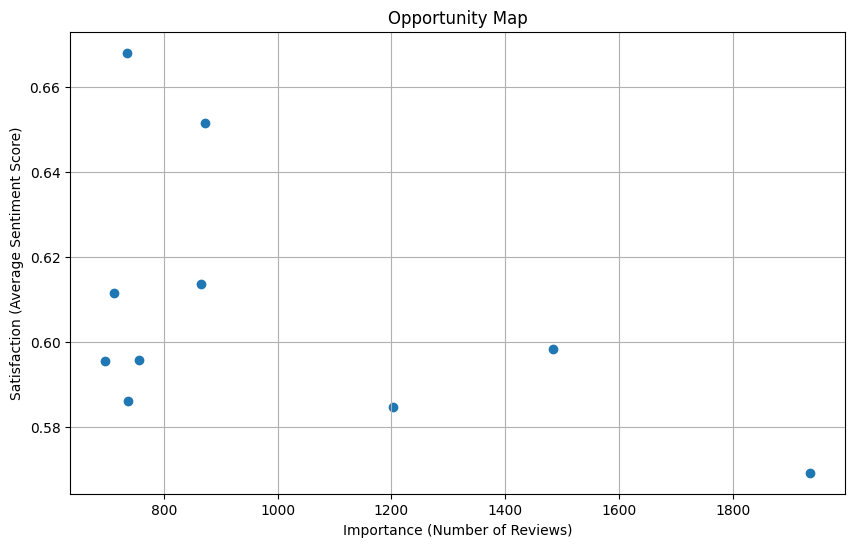

In [61]:
# Plot the opportunity map using a scatter plot
# Set the figure size to 10x6 inches for better visibility
plt.figure(figsize=(10, 6))

# Create a scatter plot with 'topic_counts1' (importance) on the x-axis 
# and 'topic_sentiments1' (satisfaction) on the y-axis
plt.scatter(topic_counts1, topic_sentiments1)

# Label the x-axis as 'Importance (Number of Reviews)'
plt.xlabel('Importance (Number of Reviews)')

# Label the y-axis as 'Satisfaction (Average Sentiment Score)'
plt.ylabel('Satisfaction (Average Sentiment Score)')

# Set the title of the plot to 'Opportunity Map'
plt.title('Opportunity Map')

# Add a grid to the plot for better readability of the points
plt.grid(True)

# Display the plot
plt.show()


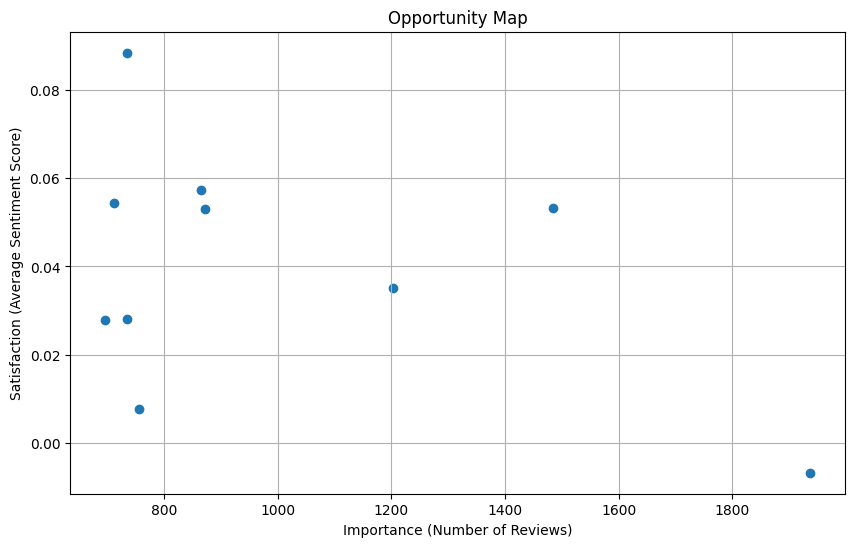

In [63]:
# Plot the opportunity map using a scatter plot
# Set the figure size to 10x6 inches for better visibility
plt.figure(figsize=(10, 6))

# Create a scatter plot with 'topic_counts2' (importance) on the x-axis 
# and 'topic_sentiments2' (satisfaction) on the y-axis
plt.scatter(topic_counts2, topic_sentiments2)

# Label the x-axis as 'Importance (Number of Reviews)'
plt.xlabel('Importance (Number of Reviews)')

# Label the y-axis as 'Satisfaction (Average Sentiment Score)'
plt.ylabel('Satisfaction (Average Sentiment Score)')

# Set the title of the plot to 'Opportunity Map'
plt.title('Opportunity Map')

# Add a grid to the plot for better readability of the points
plt.grid(True)

# Display the plot
plt.show()


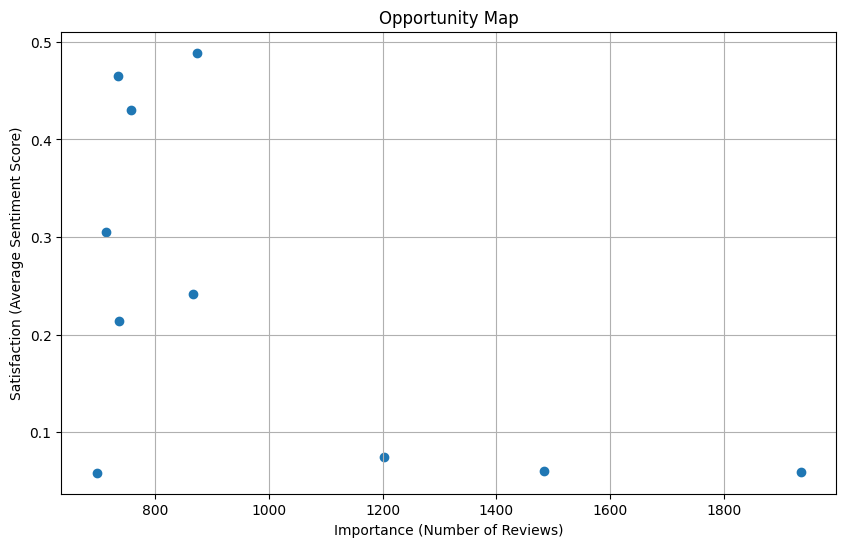

In [74]:
# Plot the opportunity map using a scatter plot
# Set the figure size to 10x6 inches for better visibility and presentation
plt.figure(figsize=(10, 6))

# Create a scatter plot with 'topic_counts3' (importance) on the x-axis 
# and 'topic_sentiments3' (satisfaction) on the y-axis
plt.scatter(topic_counts3, topic_sentiments3)

# Label the x-axis as 'Importance (Number of Reviews)' to indicate the topic frequency
plt.xlabel('Importance (Number of Reviews)')

# Label the y-axis as 'Satisfaction (Average Sentiment Score)' to show the average sentiment score
plt.ylabel('Satisfaction (Average Sentiment Score)')

# Set the title of the plot to 'Opportunity Map' to provide context for the chart
plt.title('Opportunity Map')

# Add a grid to the plot for better readability of the points
plt.grid(True)

# Display the plot
plt.show()
